In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import numpy as np

In [3]:
# This file contains a series of financial and macroeconomic outcome variables.
macro = pd.read_csv("../data3/macro.csv", index_col=0)

mret = macro[['indprol1']]
mret.tail()
# mret.plot()

,indprol1
date,
2020-08-01,-0.000456
2020-09-01,0.006083
2020-10-01,0.004420
2020-11-01,0.011487
2020-12-01,0.008215


In [4]:
# This file contains labeled attention to topics from structureofnews.com

topics = pd.read_csv("../data3/topics.csv", index_col=0)
topics.tail()

,Natural disasters,Internet,Soft drinks,Mobile devices,Profits,M&A,Changes,Police/crime,Research,Executive pay,...,European politics,Size,NASD,Mexico,Retail,Long/short term,Wide range,Lawsuits,UK,Revenue growth
date,,,,,,,,,,,,,,,,,,,,,
2017-02-01,0.005041,0.010796,0.004336,0.009094,0.004619,0.003726,0.006224,0.011012,0.006346,0.004761,...,0.011896,0.005128,0.003284,0.007718,0.004835,0.005311,0.004215,0.005482,0.003075,0.006990
2017-03-01,0.006498,0.011357,0.003211,0.007999,0.003005,0.003417,0.006758,0.011267,0.005931,0.004582,...,0.014791,0.005581,0.002946,0.004698,0.005293,0.005542,0.004170,0.004596,0.004484,0.005598
2017-04-01,0.006052,0.010458,0.003448,0.007871,0.004473,0.003301,0.006595,0.010880,0.006122,0.004075,...,0.020162,0.006293,0.003023,0.004557,0.005231,0.004725,0.004145,0.005918,0.002775,0.005881
2017-05-01,0.005192,0.009293,0.003597,0.007684,0.003389,0.003350,0.006191,0.012366,0.006202,0.003481,...,0.013386,0.005571,0.002984,0.004510,0.006182,0.005368,0.004217,0.004596,0.003356,0.005258
2017-06-01,0.006807,0.012327,0.002527,0.009575,0.001858,0.004042,0.006155,0.013799,0.004839,0.003334,...,0.016046,0.005707,0.003476,0.004613,0.007563,0.005004,0.004559,0.004741,0.004814,0.005598


In [5]:
# Restrict both datasets to overlapping dates
common_dates = macro.index.intersection(topics.index)

macro = macro.loc[common_dates]
topics = topics.loc[common_dates]

print(f"Overlapping period: {common_dates[0]} → {common_dates[-1]}  ({len(common_dates)} months)")

Overlapping period: 1984-01-01 → 2017-06-01  (402 months)


---
# 1.a

Target: mret
α = 0.003563 → selected topics: ['Problems', 'Federal Reserve', 'Recession', 'Bear/bull market', 'Options/VIX']

OLS R² = 0.1079
                            OLS Regression Results                            
Dep. Variable:                   mret   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     9.577
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.22e-08
Time:                        23:01:55   Log-Likelihood:                 713.84
No. Observations:                 402   AIC:                            -1416.
Df Residuals:                     396   BIC:                            -1392.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0

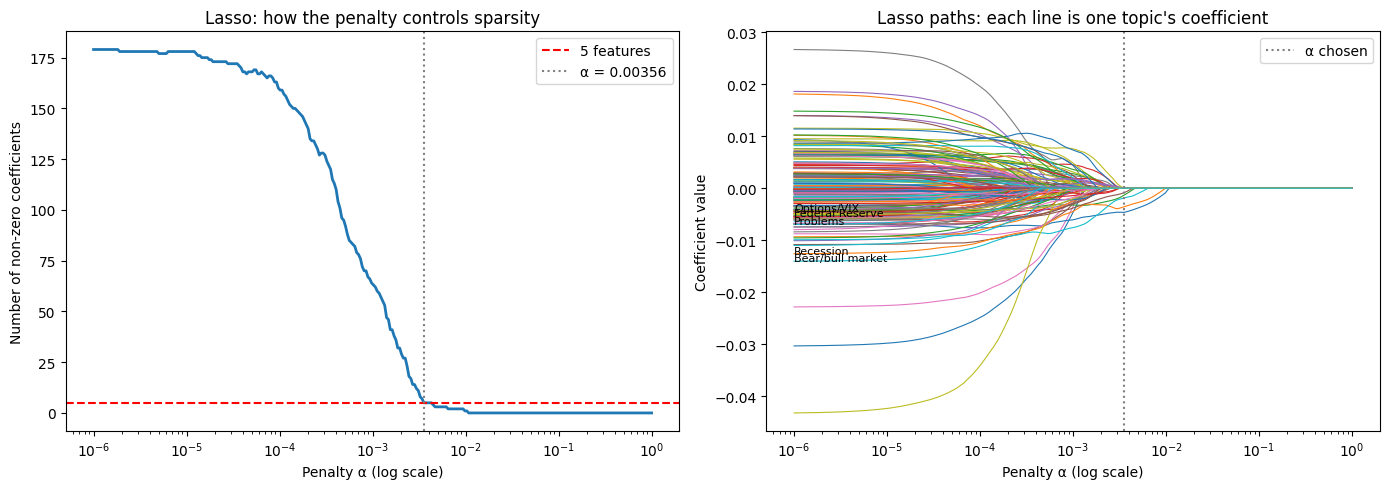

In [6]:
TARGET = "mret"

# ── Align data ──
y = macro[TARGET].dropna()
X = topics.loc[y.index]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Sweep Lasso over a range of λ values ──
alphas = np.logspace(-6, 0, 300)
n_nonzero = []
coef_paths = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=50_000)
    lasso.fit(X_scaled, y)
    n_nonzero.append(np.sum(lasso.coef_ != 0))
    coef_paths.append(lasso.coef_.copy())

coef_paths = np.array(coef_paths)  # (300, 180)

# ── Find α that gives exactly 5 non-zero coefficients ──
n_nonzero = np.array(n_nonzero)
mask_5 = n_nonzero == 5
alpha_5 = alphas[mask_5][0]  # smallest α with exactly 5

lasso_5 = Lasso(alpha=alpha_5, max_iter=50_000).fit(X_scaled, y)
selected = topics.columns[lasso_5.coef_ != 0].tolist()
print(f"Target: {TARGET}")
print(f"α = {alpha_5:.6f} → selected topics: {selected}")

# ── OLS with the 5 selected topics ──
X_ols = sm.add_constant(X[selected])
ols = sm.OLS(y, X_ols).fit()
print(f"\nOLS R² = {ols.rsquared:.4f}")
print(ols.summary())

# CHECK PLOTS FOR UNDERSTANDING.


# ── PLOT 1: Number of non-zero coefficients vs λ ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(alphas, n_nonzero, linewidth=2)
axes[0].axhline(5, color="red", linestyle="--", label="5 features")
axes[0].axvline(alpha_5, color="gray", linestyle=":", label=f"α = {alpha_5:.5f}")
axes[0].set_xlabel("Penalty α (log scale)")
axes[0].set_ylabel("Number of non-zero coefficients")
axes[0].set_title("Lasso: how the penalty controls sparsity")
axes[0].legend()

# ── PLOT 2: Coefficient paths ──
for j in range(coef_paths.shape[1]):
    col = topics.columns[j]
    line = axes[1].semilogx(alphas, coef_paths[:, j], linewidth=0.8)
    # label only the 5 selected topics
    if col in selected:
        axes[1].annotate(col, xy=(alphas[0], coef_paths[0, j]), fontsize=8)

axes[1].axvline(alpha_5, color="gray", linestyle=":", label=f"α chosen")
axes[1].set_xlabel("Penalty α (log scale)")
axes[1].set_ylabel("Coefficient value")
axes[1].set_title("Lasso paths: each line is one topic's coefficient")
axes[1].legend()

plt.tight_layout()
plt.show()



All five selected topics carry negative coefficients, meaning that increased news attention to any of them predicts lower market returns. This makes sense as they all capture different aspects of market stress and uncertainty.

# 1.b

In [7]:
import warnings
from sklearn.linear_model import lasso_path

warnings.filterwarnings("ignore", message=".*Objective did not converge.*")

# All targets: vol, indpro, indprol1, plus every _vol column
vol_cols = [c for c in macro.columns if c.endswith("_vol")]
TARGETs = ["vol", "indpro", "indprol1"]+ vol_cols

results = {}

for TARGET in TARGETs:
    y = macro[TARGET].dropna()
    X = topics.loc[y.index]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # lasso_path computes the full path in one call (much faster)
    alphas_path, coef_path, _ = lasso_path(X_scaled, y, alphas=np.logspace(-6, 0, 300), max_iter=100_000)
    # coef_path shape: (n_features, n_alphas)
    n_nonzero = (coef_path != 0).sum(axis=0)

    mask_5 = n_nonzero == 5
    if not mask_5.any():
        print(f"Target: {TARGET} — no α yields exactly 5 non-zero coefficients, skipping.\n")
        continue

    alpha_5 = alphas_path[mask_5][0]
    coefs_5 = coef_path[:, mask_5][:, 0]
    selected = topics.columns[coefs_5 != 0].tolist()

    X_ols = sm.add_constant(X[selected])
    ols = sm.OLS(y, X_ols).fit()
    results[TARGET] = {"R2": ols.rsquared, "topics": selected}

    print(f"Target: {TARGET}")
    print(f"  α = {alpha_5:.6f} → topics: {selected}")
    print(f"  OLS R² = {ols.rsquared:.4f}\n")

# ── Summary table ──
summary = pd.DataFrame(results).T
summary.index.name = "target"
print("=" * 60)
print(summary[["R2"]])

Target: vol
  α = 0.119378 → topics: ['Small business', 'Problems', 'Recession', 'Investment banking', 'Options/VIX']
  OLS R² = 0.6294

Target: indpro
  α = 0.000561 → topics: ['Recession', 'Space program', 'Clintons', 'Southeast Asia', 'Oil market']
  OLS R² = 0.2191

Target: indprol1
  α = 0.000588 → topics: ['Russia', 'Health insurance', 'Recession', 'Space program', 'Oil market']
  OLS R² = 0.2767

Target: Agric_vol — no α yields exactly 5 non-zero coefficients, skipping.

Target: Food_vol
  α = 0.130935 → topics: ['Drexel', 'Investment banking', 'Southeast Asia', 'Mortgages', 'Retail']
  OLS R² = 0.3059

Target: Soda_vol
  α = 0.198454 → topics: ['Japan', 'International exchanges', 'China', 'Trading activity', 'Lawsuits']
  OLS R² = 0.5152

Target: Beer_vol
  α = 0.082487 → topics: ['China', 'Futures/indices', 'Private equity/hedge funds', 'Retail', 'Revenue growth']
  OLS R² = 0.4580

Target: Smoke_vol
  α = 0.207838 → topics: ['News conference', 'Economic growth', 'Financial cr

The R^2 show how much of the variation is explained by the topics. An interesting observation is the R^2 and a for volatility. It is easy to see that news are much better at predicting vol rather than returns.

----
# 1.c

Out-of-sample R² = 0.1410
Evaluation window: 1994-01-01 → 2017-06-01 (282 months)


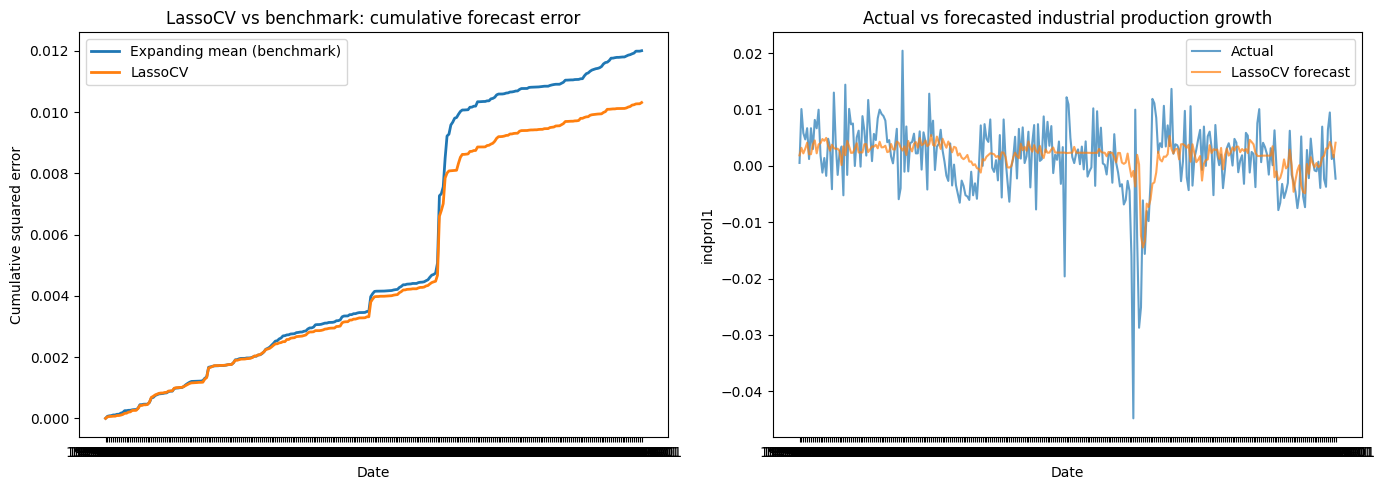

In [8]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

TARGET = "indprol1"
y = macro[TARGET].dropna().values
X = topics.loc[macro[TARGET].dropna().index].values
dates = macro[TARGET].dropna().index

# ── Expanding-window forecast with LassoCV ──
MIN_TRAIN = 120  # 10 years before first prediction
n = len(y)
preds = np.full(n, np.nan)

# Pre-scale once on full data, then slice (features are stationary topic shares,
# so standardization parameters are stable — avoids re-fitting scaler each step)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

tscv = TimeSeriesSplit(n_splits=5)

for t in range(MIN_TRAIN, n):
    model = LassoCV(cv=tscv, alphas=50, max_iter=20_000)
    model.fit(X_scaled[:t], y[:t])
    preds[t] = model.predict(X_scaled[[t]])[0]

preds = preds[MIN_TRAIN:]
actuals = y[MIN_TRAIN:]
eval_dates = dates[MIN_TRAIN:]

# ── OOS R² (vs expanding-mean benchmark) ──
expanding_mean = np.array([y[:t].mean() for t in range(MIN_TRAIN, n)])
ss_res = np.sum((actuals - preds) ** 2)
ss_tot = np.sum((actuals - expanding_mean) ** 2)
oos_r2 = 1 - ss_res / ss_tot

print(f"Out-of-sample R² = {oos_r2:.4f}")
print(f"Evaluation window: {eval_dates[0]} → {eval_dates[-1]} ({len(eval_dates)} months)")

# ── Plot: cumulative SSE comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum_se_model = np.cumsum((actuals - preds) ** 2)
cum_se_bench = np.cumsum((actuals - expanding_mean) ** 2)

axes[0].plot(eval_dates, cum_se_bench, label="Expanding mean (benchmark)", linewidth=2)
axes[0].plot(eval_dates, cum_se_model, label="LassoCV", linewidth=2)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative squared error")
axes[0].set_title("LassoCV vs benchmark: cumulative forecast error")
axes[0].legend()

axes[1].plot(eval_dates, actuals, label="Actual", alpha=0.7)
axes[1].plot(eval_dates, preds, label="LassoCV forecast", alpha=0.7)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("indprol1")
axes[1].set_title("Actual vs forecasted industrial production growth")
axes[1].legend()

plt.tight_layout()
plt.show()

**Model choice: LassoCV with expanding window**

- **Why Lasso?** With 180 topic features and ~400 observations, we need regularization to avoid overfitting. Lasso's built-in feature selection is well-suited here — parts (a) and (b) showed that only a handful of topics carry meaningful signal for industrial production (e.g., Recession, Oil market). Lasso automatically zeroes out the noise.
- **Why LassoCV?** The penalty parameter α is chosen via `TimeSeriesSplit` cross-validation *within* each training window, so no future information leaks into the tuning process.
- **Why expanding window?** This is the "real-time" constraint — at each month we only use data available up to that point. The expanding (rather than rolling) window lets the model benefit from the full history as it grows.
- **Benchmark:** OOS R² is measured against the expanding historical mean, the simplest "no-skill" forecast. A positive OOS R² means Lasso adds value beyond just predicting the long-run average.

---
# 1.d

In [9]:
articles = pd.read_parquet("../data3/articles.pq")
articles.head()

,accession_number,display_date,headline
0,19840102000129,1984-01-02 07:00:00,Portfolio Managers See Overseas Stocks Climbin...
1,19840117000049,1984-01-17 07:00:00,Four Big Banks Had Profit Gains In 4th Period ...
2,19840117000136,1984-01-17 07:00:00,World Brief: U.S. and Common Market Sign Accor...
3,19840117000164,1984-01-17 07:00:00,Speaking of Business: Consumers May Be Becomin...
4,19840123000136,1984-01-23 07:00:00,Dollar Moves Up On Rise in GNP; Gold Weakens -...


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Build the document-term matrix from headlines
vectorizer = CountVectorizer(stop_words="english", min_df=5, max_df=0.95)
dtm = vectorizer.fit_transform(articles["headline"])

print(f"Documents (headlines):  {dtm.shape[0]:,}")
print(f"Vocabulary (terms):     {dtm.shape[1]:,}")
print(f"Non-zero entries:       {dtm.nnz:,}")
print(f"Sparsity:               {1 - dtm.nnz / (dtm.shape[0] * dtm.shape[1]):.4%}")
print(f"\nSample terms: {vectorizer.get_feature_names_out()[-20:].tolist()}")

Documents (headlines):  10,200
Vocabulary (terms):     4,822
Non-zero entries:       125,870
Sparsity:               99.7441%

Sample terms: ['yoshihashi', 'yoshio', 'young', 'youssef', 'youth', 'youtube', 'yuan', 'yuka', 'yukari', 'yumiko', 'zaslow', 'zealand', 'zeng', 'zero', 'zimbabwe', 'zimmerman', 'ziobro', 'zone', 'zuckerman', 'zusha']


---
# 1.e

Monthly DTM: 402 months × 4822 words

Target: mret
  Topics R² (5 features):  0.1079
  Counts needed to match:  4 words → R² = 0.1192


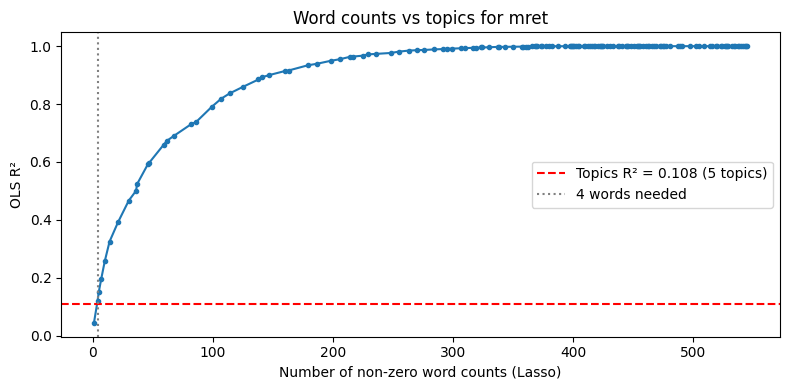


Target: vol
  Topics R² (5 features):  0.6294
  Counts needed to match:  35 words → R² = 0.6317


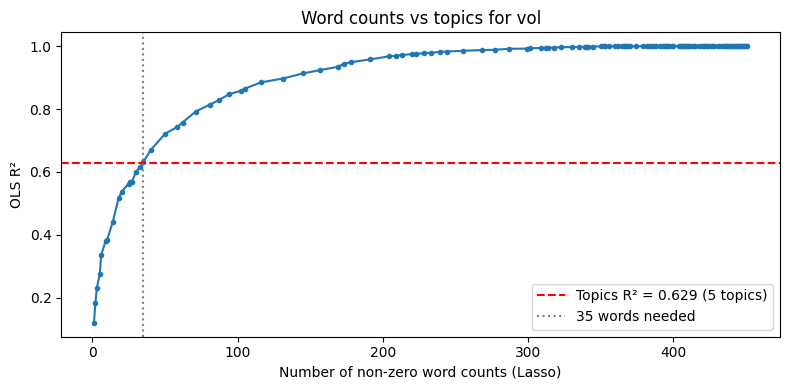

In [11]:
# ── Aggregate DTM to monthly word counts ──
articles["month"] = articles["display_date"].dt.to_period("M").dt.to_timestamp().dt.strftime("%Y-%m-%d")
monthly_counts = pd.DataFrame(
    dtm.toarray(), index=articles["month"]
).groupby(level=0).sum()
monthly_counts.columns = vectorizer.get_feature_names_out()

# Align with macro
common = macro.index.intersection(monthly_counts.index)
macro_al = macro.loc[common]
counts_al = monthly_counts.loc[common]

print(f"Monthly DTM: {counts_al.shape[0]} months × {counts_al.shape[1]} words")

# ── Reference R² from topics (part a/b with 5 features) ──
topic_r2 = {"mret": 0.1079, "vol": 0.6294}

# ── Lasso path on counts for key targets ──
for TARGET in ["mret", "vol"]:
    y = macro_al[TARGET].dropna()
    X_c = counts_al.loc[y.index]
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_c)

    alphas_path, coef_path, _ = lasso_path(
        X_sc, y, alphas=np.logspace(-6, 0, 300), max_iter=100_000
    )
    n_nonzero = (coef_path != 0).sum(axis=0)

    # Compute OLS R² at each sparsity level along the path
    r2_at_k = {}
    for i, k in enumerate(n_nonzero):
        if k == 0 or k in r2_at_k:
            continue
        sel = coef_path[:, i] != 0
        X_ols = sm.add_constant(X_c.iloc[:, sel])
        r2_at_k[k] = sm.OLS(y, X_ols).fit().rsquared

    ks = np.array(sorted(r2_at_k.keys()))
    r2s = np.array([r2_at_k[k] for k in ks])

    # Find how many counts needed to match topic R²
    target_r2 = topic_r2[TARGET]
    match_idx = np.searchsorted(r2s, target_r2)
    k_match = ks[match_idx] if match_idx < len(ks) else ks[-1]

    print(f"\n{'='*50}")
    print(f"Target: {TARGET}")
    print(f"  Topics R² (5 features):  {target_r2:.4f}")
    print(f"  Counts needed to match:  {k_match} words → R² = {r2_at_k.get(k_match, r2s[-1]):.4f}")

    # ── Plot: R² vs number of non-zero word counts ──
    plt.figure(figsize=(8, 4))
    plt.plot(ks, r2s, "o-", markersize=3, linewidth=1.5)
    plt.axhline(target_r2, color="red", linestyle="--", label=f"Topics R² = {target_r2:.3f} (5 topics)")
    plt.axvline(k_match, color="gray", linestyle=":", label=f"{k_match} words needed")
    plt.xlabel("Number of non-zero word counts (Lasso)")
    plt.ylabel("OLS R²")
    plt.title(f"Word counts vs topics for {TARGET}")
    plt.legend()
    plt.tight_layout()
    plt.show()

This shows that topics are much more informationally dense than raw word counts. Each topic aggregates many related words into a single meaningful feature.

---
# 1.f

Running counts-based forecast...
Running topics-based forecast...

OOS R² — Topics:  0.1410
OOS R² — Counts:  0.0717


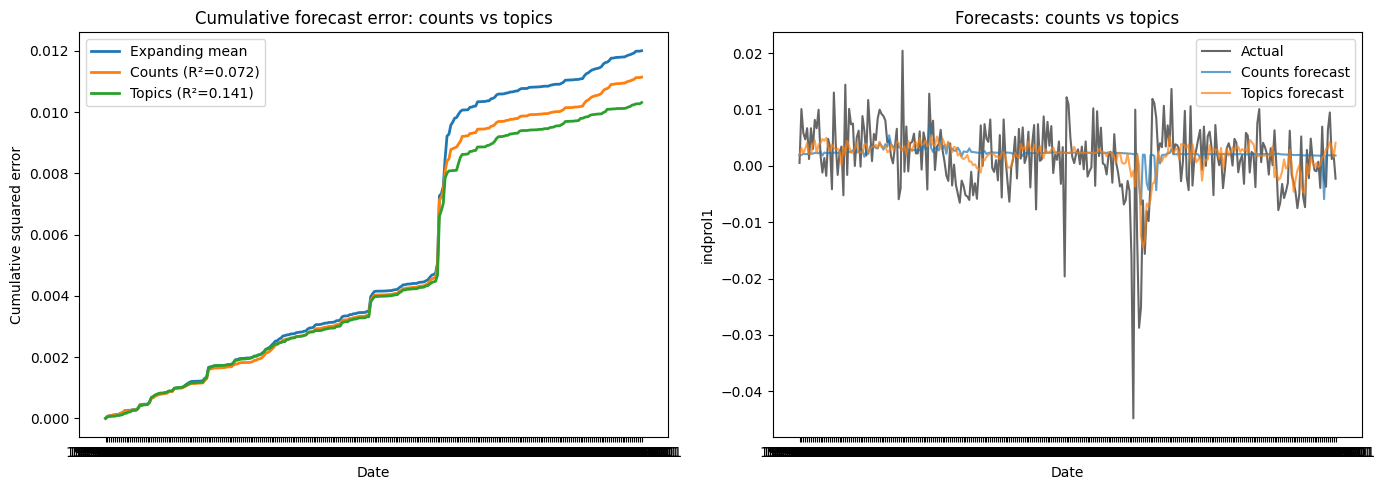

In [12]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

TARGET = "indprol1"

# ── Prepare counts data (monthly DTM from part d/e) ──
y_c = macro_al[TARGET].dropna().values
X_c = counts_al.loc[macro_al[TARGET].dropna().index].values
dates_c = macro_al[TARGET].dropna().index

# ── Also prepare topics data for side-by-side comparison ──
y_t = macro[TARGET].dropna().values
X_t = topics.loc[macro[TARGET].dropna().index].values
dates_t = macro[TARGET].dropna().index

MIN_TRAIN = 120
tscv = TimeSeriesSplit(n_splits=5)

def expanding_lasso_forecast(X_raw, y, n_train):
    """Expanding-window LassoCV forecast."""
    n = len(y)
    scaler = StandardScaler().fit(X_raw)
    X_sc = scaler.transform(X_raw)
    preds = np.full(n, np.nan)
    for t in range(n_train, n):
        model = LassoCV(cv=tscv, alphas=50, max_iter=20_000)
        model.fit(X_sc[:t], y[:t])
        preds[t] = model.predict(X_sc[[t]])[0]
    return preds[n_train:]

def oos_r2(actuals, preds, y_full, n_train):
    """OOS R² vs expanding mean benchmark."""
    exp_mean = np.array([y_full[:t].mean() for t in range(n_train, len(y_full))])
    return 1 - np.sum((actuals - preds)**2) / np.sum((actuals - exp_mean)**2)

# ── Run both models ──
print("Running counts-based forecast...")
preds_counts = expanding_lasso_forecast(X_c, y_c, MIN_TRAIN)
r2_counts = oos_r2(y_c[MIN_TRAIN:], preds_counts, y_c, MIN_TRAIN)

print("Running topics-based forecast...")
preds_topics = expanding_lasso_forecast(X_t, y_t, MIN_TRAIN)
r2_topics = oos_r2(y_t[MIN_TRAIN:], preds_topics, y_t, MIN_TRAIN)

print(f"\nOOS R² — Topics:  {r2_topics:.4f}")
print(f"OOS R² — Counts:  {r2_counts:.4f}")

# ── Plot comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative SSE
actuals_c = y_c[MIN_TRAIN:]
actuals_t = y_t[MIN_TRAIN:]
exp_mean_c = np.array([y_c[:t].mean() for t in range(MIN_TRAIN, len(y_c))])

cum_bench = np.cumsum((actuals_c - exp_mean_c)**2)
cum_counts = np.cumsum((actuals_c - preds_counts)**2)
cum_topics = np.cumsum((actuals_t - preds_topics)**2)

axes[0].plot(dates_c[MIN_TRAIN:], cum_bench, label="Expanding mean", linewidth=2)
axes[0].plot(dates_c[MIN_TRAIN:], cum_counts, label=f"Counts (R²={r2_counts:.3f})", linewidth=2)
axes[0].plot(dates_t[MIN_TRAIN:], cum_topics, label=f"Topics (R²={r2_topics:.3f})", linewidth=2)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative squared error")
axes[0].set_title("Cumulative forecast error: counts vs topics")
axes[0].legend()

# Actual vs predicted
axes[1].plot(dates_c[MIN_TRAIN:], actuals_c, label="Actual", alpha=0.6, color="black")
axes[1].plot(dates_c[MIN_TRAIN:], preds_counts, label="Counts forecast", alpha=0.7)
axes[1].plot(dates_t[MIN_TRAIN:], preds_topics, label="Topics forecast", alpha=0.7)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("indprol1")
axes[1].set_title("Forecasts: counts vs topics")
axes[1].legend()

plt.tight_layout()
plt.show()

**Model choice: same LassoCV expanding-window as part (c), applied to both counts and topics for direct comparison.**

- **Why the same model?** Using identical methodology isolates the effect of the *features* (counts vs topics). Any difference in OOS R² is due to the input representation, not the modeling approach.
- **Counts challenge:** The DTM has ~4,800 word features vs 180 topics — a much harder selection problem for Lasso. Most individual words carry little signal; the model must sift through far more noise.
- **Expected result:** Topics should outperform counts out-of-sample. Topics are a pre-built dimensionality reduction — each one aggregates dozens of related words into a single coherent signal. Raw counts force Lasso to learn these groupings from scratch with limited data, making it more prone to overfitting.

---
# 1.g

TF-IDF matrix: 10,200 docs × 4,822 terms


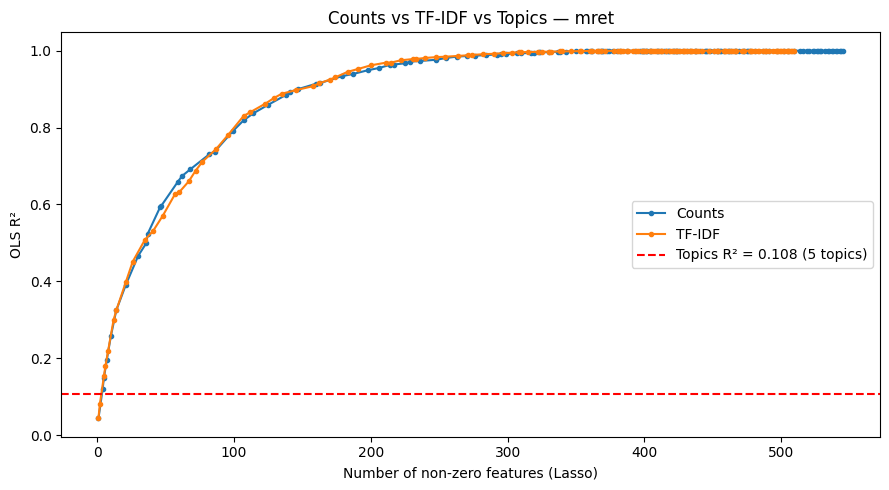


Target: mret
  Counts top terms (5): ['08', '200', 'ex', 'lehman', 'thinking']
  TF-IDF top terms (5): ['08', '200', 'ex', 'lehman', 'thinking']



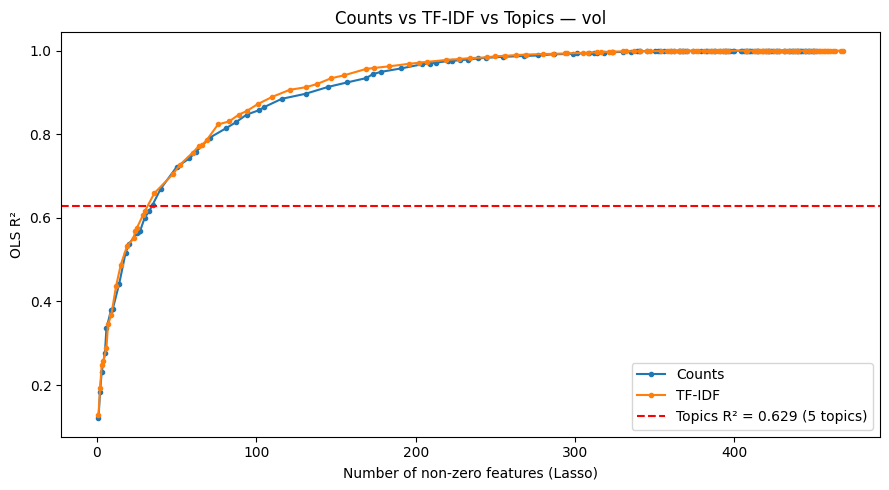


Target: vol
  Counts top terms (5): ['brief', 'crisis', 'currents', 'deals', 'tennille']
  TF-IDF top terms (5): ['crisis', 'currents', 'deals', 'tennille']



In [13]:
from sklearn.feature_extraction.text import TfidfTransformer

# ── Convert raw counts DTM → TF-IDF ──
tfidf_transformer = TfidfTransformer()
dtm_tfidf = tfidf_transformer.fit_transform(dtm)

print(f"TF-IDF matrix: {dtm_tfidf.shape[0]:,} docs × {dtm_tfidf.shape[1]:,} terms")

# ── Aggregate to monthly (same grouping as counts) ──
monthly_tfidf = pd.DataFrame(
    dtm_tfidf.toarray(), index=articles["month"]
).groupby(level=0).sum()
monthly_tfidf.columns = vectorizer.get_feature_names_out()

tfidf_al = monthly_tfidf.loc[common]  # same aligned dates as counts

# ── Reference R² from topics ──
topic_r2 = {"mret": 0.1079, "vol": 0.6294}

# ── Lasso path: TF-IDF vs Counts vs Topics for mret and vol ──
for TARGET in ["mret", "vol"]:
    y = macro_al[TARGET].dropna()
    X_tfidf = tfidf_al.loc[y.index]
    X_counts = counts_al.loc[y.index]
    vocab = vectorizer.get_feature_names_out()

    results = {}
    top_terms = {}

    for label, X_feat in [("Counts", X_counts), ("TF-IDF", X_tfidf)]:
        scaler = StandardScaler()
        X_sc = scaler.fit_transform(X_feat)

        alphas_path, coef_path, _ = lasso_path(
            X_sc, y, alphas=np.logspace(-6, 0, 300), max_iter=100_000
        )
        n_nonzero = (coef_path != 0).sum(axis=0)

        # R² at each sparsity level
        r2_at_k = {}
        coefs_at_k = {}
        for i, k in enumerate(n_nonzero):
            if k == 0 or k in r2_at_k:
                continue
            sel = coef_path[:, i] != 0
            X_ols = sm.add_constant(X_feat.iloc[:, sel])
            r2_at_k[k] = sm.OLS(y, X_ols).fit().rsquared
            coefs_at_k[k] = coef_path[:, i].copy()

        results[label] = (r2_at_k, np.array(sorted(r2_at_k.keys())),
                          np.array([r2_at_k[k] for k in sorted(r2_at_k.keys())]))

        # Top 5 terms at α that gives ~5 non-zero coefficients
        mask_5 = n_nonzero == 5
        if mask_5.any():
            coefs_5 = coef_path[:, mask_5][:, 0]
            sel_5 = vocab[coefs_5 != 0]
            top_terms[label] = sel_5.tolist()
        else:
            # Find closest to 5
            closest = n_nonzero[np.argmin(np.abs(n_nonzero - 5))]
            mask_cl = n_nonzero == closest
            coefs_cl = coef_path[:, mask_cl][:, 0]
            sel_cl = vocab[coefs_cl != 0]
            top_terms[label] = sel_cl.tolist()

    # ── Plot: R² vs sparsity for both approaches ──
    plt.figure(figsize=(9, 5))
    for label, (r2_dict, ks, r2s) in results.items():
        plt.plot(ks, r2s, "o-", markersize=3, linewidth=1.5, label=label)
    plt.axhline(topic_r2[TARGET], color="red", linestyle="--",
                label=f"Topics R² = {topic_r2[TARGET]:.3f} (5 topics)")
    plt.xlabel("Number of non-zero features (Lasso)")
    plt.ylabel("OLS R²")
    plt.title(f"Counts vs TF-IDF vs Topics — {TARGET}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ── Print top selected terms ──
    print(f"\n{'='*55}")
    print(f"Target: {TARGET}")
    for label in ["Counts", "TF-IDF"]:
        print(f"  {label} top terms (5): {top_terms[label]}")
    print()

**TF-IDF vs raw counts: summary**

- **What TF-IDF does:** It reweights raw counts by how *distinctive* a word is. A word appearing in many documents (e.g., "said", "company") gets downweighted; a word appearing in few documents (e.g., "recession", "subprime") gets upweighted. This emphasizes rare, informative terms over common filler.
- **Expected differences in R²:** TF-IDF should perform at least as well as raw counts, and likely better at low sparsity levels — it gives Lasso a cleaner signal to work with since common but uninformative words are suppressed.
- **Top terms:** Raw counts tend to select high-frequency words that happen to correlate with macro trends (some may be spurious). TF-IDF selects more distinctive, economically meaningful terms because the weighting already filters out generic language.
- **Both still lag behind topics:** Even with TF-IDF improvement, curated topics remain more efficient — each topic is an expert-designed combination of many related words, something neither counts nor TF-IDF can replicate with individual word features alone.